In [1]:
%%writefile types.h
/**
 * @file      types.h
 * @brief     Common type definitions for the entire project.
 * @details   This header defines fundamental data types, structures, and aliases
 *            to promote consistency and portability across the codebase.
 *
 * @copyright  (C) 2025, Manoel Augusto de Souza Serafim
 *             All rights reserved.
 *
 * @author     Manoel Serafim
 * @email      manoel.serafim@proton.me
 * @github     https://github.com/manoel-serafim
*/
#ifndef STD_TYPES_H_
#define STD_TYPES_H_

typedef int int32_t;
typedef unsigned int uint32_t;
typedef double float64_t;

#endif // STD_TYPES_H_

Writing types.h


In [2]:
%%writefile kmeans_1d.c

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>
#include <omp.h> //only for timing
#include "types.h"

uint32_t point_amount = 0u;
uint32_t centroid_amount = 0u;
uint32_t iteration_counter = 0u;
uint32_t iteration_limit = 0u;
float64_t sum_squared_errors = 0.0f;
float64_t epsilon = 0.0f;

const float64_t *points = NULL;
float64_t *centroids = NULL;
float64_t *sum_centroid_points = NULL;
uint32_t *amount_centroid_points = NULL;
uint32_t *assignments = NULL;

/* ---------- util CSV 1D: cada linha tem 1 número ---------- */
static uint32_t count_rows(const char *path)
{
    FILE *f = fopen(path, "r");
    if (!f)
    {
        perror(path);
        exit(1);
    }
    uint32_t rows = 0;
    char line[8192];
    while (fgets(line, sizeof(line), f))
    {
        for (char *p = line; *p; p++)
        {
            if (*p != ' ' && *p != '\t' && *p != '\n' && *p != '\r')
            {
                rows++;
                break;
            }
        }
    }
    fclose(f);
    return rows;
}

static double *read_csv_1col(const char *path,
                             uint32_t *n_out)
{
    uint32_t R = count_rows(path);
    if (R <= 0)
    {
        fprintf(stderr, "%s: arquivo vazio\n", path);
        exit(1);
    }

    double *A = malloc((unsigned long) R * sizeof(double));
    if (!A)
    {
        perror("malloc");
        exit(1);
    }

    FILE *f = fopen(path, "r");
    if (!f)
    {
        perror(path);
        free(A);
        exit(1);
    }

    char line[8192];
    uint32_t r = 0;
    while (fgets(line, sizeof(line), f) && r < R)
    {
        char *tok = strtok(line, ",; \t\n\r");
        if (!tok)
        {
            fprintf(stderr, "%s: linha %d sem valor\n", path, r+1);
            free(A);
            fclose(f);
            exit(1);
        }
        A[r++] = atof(tok);
    }
    fclose(f);
    *n_out = R;
    return A;
}

static void write_assign_csv(const char *path,
                             const uint32_t *assign,
                             uint32_t N)
{
    if (!path)
    {
        return;
    }

    FILE *f = fopen(path, "w");
    if (!f)
    {
        perror(path);
        return;
    }
    for (uint32_t i = 0; i < N; i++)
    {
        fprintf(f, "%d\n", assign[i]);
    }
    fclose(f);
}

static void write_centroids_csv(const char *path,
                                const double *C,
                                uint32_t K)
{
    if (!path)
    {
        return;
    }

    FILE *f = fopen(path, "w");
    if (!f)
    {
        perror(path);
        return;
    }
    for (uint32_t c = 0; c < K; c++)
    {
        fprintf(f, "%.6f\n", C[c]);
    }
    fclose(f);
}

static void assignment_step_1d(void)
{
    uint32_t point_index = 0u;
    uint32_t centroid_index = 0u;

    uint32_t assign_index = 0u;

    float64_t error = 0.0f;
    float64_t squared_error = 0.0f;
    float64_t squared_error_holder = 0.0f;
    sum_squared_errors = 0.0f;

    point_index = 0u;
    do
    {
        assign_index = 0u;
        error = (points[point_index]-centroids[0]); // compiler would already optimize for reuse under -O2
        squared_error = error * error;

        centroid_index = 1u;
        do
        {

            error = (points[point_index]-centroids[centroid_index]);
            squared_error_holder = error*error;
            if (squared_error > squared_error_holder)
            {
                squared_error = squared_error_holder;
                assign_index = centroid_index;
            }
            ++centroid_index;

        }
        while (centroid_index < centroid_amount);

        assignments[point_index] = assign_index;
        sum_squared_errors += squared_error;
        ++point_index;
    }
    while (point_index < point_amount);

}

static void update_step_1d(void)
{

    memset(sum_centroid_points, 0.0f, centroid_amount*sizeof(float64_t));
    memset(amount_centroid_points, 0u, centroid_amount*sizeof(uint32_t));

    uint32_t point_index = 0u;
    uint32_t centroid_index = 0u;
    do
    {
        centroid_index = assignments[point_index];
        amount_centroid_points[centroid_index]++;
        sum_centroid_points[centroid_index] += points[point_index];
        ++point_index;
    }
    while (point_index < point_amount);

    centroid_index = 0u;
    do
    {
        centroids[centroid_index] = (amount_centroid_points[centroid_index] > 0) ? (sum_centroid_points[centroid_index] / amount_centroid_points[centroid_index]) : points[0];
        ++centroid_index;
    }
    while (centroid_index < centroid_amount);


}

static void kmeans_1d(void)
{
    float64_t sse_holder = 1e300;
    float64_t relative_change = 0.0f;

    sum_centroid_points = calloc((size_t) centroid_amount, sizeof(float64_t));
    amount_centroid_points = calloc((size_t) centroid_amount, sizeof(uint32_t));
    if (!sum_centroid_points || !amount_centroid_points)
    {
        perror("calloc");
        exit(1);
    }

    for (iteration_counter = 0; iteration_counter < iteration_limit; ++iteration_counter)
    {
        assignment_step_1d();
        relative_change = fabs(sum_squared_errors - sse_holder) / (sse_holder > 0.0 ? sse_holder : 1.0);
        if (relative_change < epsilon)
        {
            ++iteration_counter;
            break;
        }
        else
        {
            update_step_1d();
            sse_holder = sum_squared_errors;
        }

    }
    free(sum_centroid_points);
    free(amount_centroid_points);
}

int main(int argc,
         char **argv)
{
    if (argc < 3)
    {
        printf("Uso: %s dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] [assign.csv] [centroids.csv]\n", argv[0]);
        printf("Obs: arquivos CSV com 1 coluna (1 valor por linha), sem cabeçalho.\n");
        return 1;
    }

    const char *const path_points = argv[1];
    const char *const path_centroids = argv[2];
    iteration_limit = (argc > 3) ? (uint32_t) atoi(argv[3]) : 50u;
    epsilon = (argc > 4) ? atof(argv[4]) : 1e-4;
    const char *path_assignment = (argc > 5) ? argv[5] : NULL;
    const char *path_output_centroid = (argc > 6) ? argv[6] : NULL;

    if (iteration_limit <= 0 || epsilon <= 0.0)
    {
        fprintf(stderr, "max_iter>0 e eps>0\n");
        return 1;
    }


    points = read_csv_1col(path_points, &point_amount);
    centroids = read_csv_1col(path_centroids, &centroid_amount);
    assignments = malloc((size_t) point_amount * sizeof(uint32_t));
    if (!assignments)
    {
        perror("malloc");
        free(centroids);
        free((void *) points);
        return 1;
    }

    double start_time = omp_get_wtime();

    kmeans_1d();

    double end_time = omp_get_wtime();
    double elapsed_ms = (end_time - start_time) * 1000.0;

    printf("K-means 1D (sequential)\n");
    printf("N=%u K=%u max_iter=%u eps=%g threads=1\n",
           point_amount, centroid_amount, iteration_limit, epsilon);
    printf("Iterações: %u | SSE final: %.10f | Tempo: %.6f ms\n",
           iteration_counter, sum_squared_errors, elapsed_ms);

    write_assign_csv(path_assignment, assignments, point_amount);
    write_centroids_csv(path_output_centroid, centroids, centroid_amount);

    free(assignments);
    free(centroids);
    free((void *) points);
    return 0;
}

Writing kmeans_1d.c


In [3]:
%%bash
gcc -O3 -Wall kmeans_1d.c -o kmeans_1d_sequential -lm -fopenmp -I.

In [7]:
%%writefile kmeans_1d_mpi.c
#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <mpi.h>
#include "types.h"

uint32_t point_amount = 0u;
uint32_t centroid_amount = 0u;
uint32_t iteration_counter = 0u;
uint32_t iteration_limit = 0u;
float64_t sum_squared_errors = 0.0f;
float64_t epsilon = 0.0f;

float64_t *points_global = NULL;
uint32_t *assignments_global = NULL;

uint32_t local_point_start = 0u;
uint32_t local_point_count = 0u;
float64_t *points_local = NULL;
uint32_t *assignments_local = NULL;

float64_t *centroids = NULL;

float64_t *sum_centroid_points_local = NULL;
uint32_t *amount_centroid_points_local = NULL;
float64_t *sum_centroid_points_global = NULL;
uint32_t *amount_centroid_points_global = NULL;

int mpi_rank = 0;
int mpi_size = 1;

double comm_time_total = 0.0;

static uint32_t count_rows(const char *path)
{
    FILE *f = fopen(path, "r");
    if (!f)
    {
        perror(path);
        exit(1);
    }
    uint32_t rows = 0;
    char line[8192];
    while (fgets(line, sizeof(line), f))
    {
        for (char *p = line; *p; p++)
        {
            if (*p != ' ' && *p != '\t' && *p != '\n' && *p != '\r')
            {
                rows++;
                break;
            }
        }
    }
    fclose(f);
    return rows;
}

static double *read_csv_1col(const char *path, uint32_t *n_out)
{
    uint32_t R = count_rows(path);
    if (R <= 0)
    {
        fprintf(stderr, "%s: arquivo vazio\n", path);
        exit(1);
    }

    double *A = malloc((unsigned long) R * sizeof(double));
    if (!A)
    {
        perror("malloc");
        exit(1);
    }

    FILE *f = fopen(path, "r");
    if (!f)
    {
        perror(path);
        free(A);
        exit(1);
    }

    char line[8192];
    uint32_t r = 0;
    while (fgets(line, sizeof(line), f) && r < R)
    {
        char *tok = strtok(line, ",; \t\n\r");
        if (!tok)
        {
            fprintf(stderr, "%s: linha %d sem valor\n", path, r+1);
            free(A);
            fclose(f);
            exit(1);
        }
        A[r++] = atof(tok);
    }
    fclose(f);
    *n_out = R;
    return A;
}

static void write_assign_csv(const char *path, const uint32_t *assign, uint32_t N)
{
    if (!path) return;

    FILE *f = fopen(path, "w");
    if (!f)
    {
        perror(path);
        return;
    }
    for (uint32_t i = 0; i < N; i++)
    {
        fprintf(f, "%u\n", assign[i]);
    }
    fclose(f);
}

static void write_centroids_csv(const char *path, const double *C, uint32_t K)
{
    if (!path) return;

    FILE *f = fopen(path, "w");
    if (!f)
    {
        perror(path);
        return;
    }
    for (uint32_t c = 0; c < K; c++)
    {
        fprintf(f, "%.6f\n", C[c]);
    }
    fclose(f);
}

static void distribute_points(void)
{
    uint32_t points_per_proc = point_amount / (uint32_t) mpi_size;
    uint32_t remainder = point_amount % (uint32_t) mpi_size;

    if ((uint32_t) mpi_rank < remainder)
    {
        local_point_count = points_per_proc + 1;
        local_point_start = (uint32_t) mpi_rank * local_point_count;
    }
    else
    {
        local_point_count = points_per_proc;
        local_point_start = remainder * (points_per_proc + 1) +
                           ((uint32_t) mpi_rank - remainder) * points_per_proc;
    }

    points_local = malloc((size_t) local_point_count * sizeof(float64_t));
    assignments_local = malloc((size_t) local_point_count * sizeof(uint32_t));

    if (!points_local || !assignments_local)
    {
        perror("malloc local");
        MPI_Abort(MPI_COMM_WORLD, 1);
    }

    double comm_start = MPI_Wtime();

    if (mpi_rank == 0)
    {
        // Rank 0 copies its own local part from points_global
        memcpy(points_local, points_global + local_point_start, (size_t) local_point_count * sizeof(float64_t));

        for (int p = 1; p < mpi_size; p++)
        {
            uint32_t p_count;
            uint32_t p_start_offset;

            if ((uint32_t) p < remainder) {
                p_count = points_per_proc + 1;
                p_start_offset = (uint32_t) p * p_count;
            } else {
                p_count = points_per_proc;
                p_start_offset = remainder * (points_per_proc + 1) + ((uint32_t) p - remainder) * points_per_proc;
            }
            MPI_Send(&points_global[p_start_offset], (int) p_count, MPI_DOUBLE, p, 0, MPI_COMM_WORLD);
        }
    }
    else
    {
        MPI_Recv(points_local, (int) local_point_count, MPI_DOUBLE, 0, 0, MPI_COMM_WORLD, MPI_STATUS_IGNORE);
    }

    comm_time_total += MPI_Wtime() - comm_start;
}

static void assignment_step_local(float64_t *sse_local)
{
    *sse_local = 0.0;

    for (uint32_t i = 0; i < local_point_count; i++)
    {
        uint32_t best_centroid = 0u;
        float64_t min_dist_sq = 1e300;

        for (uint32_t c = 0; c < centroid_amount; c++)
        {
            float64_t error = points_local[i] - centroids[c];
            float64_t dist_sq = error * error;

            if (dist_sq < min_dist_sq)
            {
                min_dist_sq = dist_sq;
                best_centroid = c;
            }
        }

        assignments_local[i] = best_centroid;
        *sse_local += min_dist_sq;
    }
}

static void update_step_local(void)
{
    memset(sum_centroid_points_local, 0, (size_t) centroid_amount * sizeof(float64_t));
    memset(amount_centroid_points_local, 0, (size_t) centroid_amount * sizeof(uint32_t));

    for (uint32_t i = 0; i < local_point_count; i++)
    {
        uint32_t c = assignments_local[i];
        sum_centroid_points_local[c] += points_local[i];
        amount_centroid_points_local[c]++;
    }
}

static void kmeans_mpi(void)
{
    float64_t sse_holder = 1e300;
    float64_t sse_local = 0.0;

    sum_centroid_points_local = calloc((size_t) centroid_amount, sizeof(float64_t));
    amount_centroid_points_local = calloc((size_t) centroid_amount, sizeof(uint32_t));
    sum_centroid_points_global = calloc((size_t) centroid_amount, sizeof(float64_t));
    amount_centroid_points_global = calloc((size_t) centroid_amount, sizeof(uint32_t));

    if (!sum_centroid_points_local || !amount_centroid_points_local ||
        !sum_centroid_points_global || !amount_centroid_points_global)
    {
        perror("calloc");
        MPI_Abort(MPI_COMM_WORLD, 1);
    }

    for (iteration_counter = 0; iteration_counter < iteration_limit; iteration_counter++)
    {
        double comm_start;

        comm_start = MPI_Wtime();
        MPI_Bcast(centroids, (int) centroid_amount, MPI_DOUBLE, 0, MPI_COMM_WORLD);
        comm_time_total += MPI_Wtime() - comm_start;

        assignment_step_local(&sse_local);

        comm_start = MPI_Wtime();
        MPI_Reduce(&sse_local, &sum_squared_errors, 1, MPI_DOUBLE, MPI_SUM, 0, MPI_COMM_WORLD);
        comm_time_total += MPI_Wtime() - comm_start;

        int converged = 0;
        if (mpi_rank == 0)
        {
            float64_t relative_change = fabs(sum_squared_errors - sse_holder) /
                                       (sse_holder > 0.0 ? sse_holder : 1.0);
            if (relative_change < epsilon)
            {
                converged = 1;
            }
            sse_holder = sum_squared_errors;
        }

        comm_start = MPI_Wtime();
        MPI_Bcast(&converged, 1, MPI_INT, 0, MPI_COMM_WORLD);
        comm_time_total += MPI_Wtime() - comm_start;

        if (converged)
        {
            iteration_counter++;
            break;
        }

        update_step_local();

        comm_start = MPI_Wtime();
        MPI_Allreduce(sum_centroid_points_local, sum_centroid_points_global,
                     (int) centroid_amount, MPI_DOUBLE, MPI_SUM, MPI_COMM_WORLD);
        MPI_Allreduce(amount_centroid_points_local, amount_centroid_points_global,
                     (int) centroid_amount, MPI_UNSIGNED, MPI_SUM, MPI_COMM_WORLD);
        comm_time_total += MPI_Wtime() - comm_start;

        for (uint32_t c = 0; c < centroid_amount; c++)
        {
            if (amount_centroid_points_global[c] > 0)
            {
                centroids[c] = sum_centroid_points_global[c] / amount_centroid_points_global[c];
            }
        }
    }

    free(sum_centroid_points_local);
    free(amount_centroid_points_local);
    free(sum_centroid_points_global);
    free(amount_centroid_points_global);
}

static void gather_assignments(void)
{
    double comm_start = MPI_Wtime();

    if (mpi_rank == 0)
    {
        memcpy(assignments_global, assignments_local, (size_t) local_point_count * sizeof(uint32_t));

        uint32_t points_per_proc = point_amount / (uint32_t) mpi_size;
        uint32_t remainder = point_amount % (uint32_t) mpi_size;

        for (int p = 1; p < mpi_size; p++)
        {
            uint32_t p_count;
            uint32_t p_start_offset;

            if ((uint32_t) p < remainder) {
                p_count = points_per_proc + 1;
                p_start_offset = (uint32_t) p * p_count;
            } else {
                p_count = points_per_proc;
                p_start_offset = remainder * (points_per_proc + 1) + ((uint32_t) p - remainder) * points_per_proc;
            }

            MPI_Recv(&assignments_global[p_start_offset], (int) p_count, MPI_UNSIGNED, p, 1, MPI_COMM_WORLD, MPI_STATUS_IGNORE);
        }
    }
    else
    {
        MPI_Send(assignments_local, (int) local_point_count, MPI_UNSIGNED, 0, 1, MPI_COMM_WORLD);
    }

    comm_time_total += MPI_Wtime() - comm_start;
}

int main(int argc, char **argv)
{
    MPI_Init(&argc, &argv);
    MPI_Comm_rank(MPI_COMM_WORLD, &mpi_rank);
    MPI_Comm_size(MPI_COMM_WORLD, &mpi_size);

    if (argc < 3)
    {
        if (mpi_rank == 0)
        {
            printf("Uso: mpirun -np P %s dados.csv centroides_iniciais.csv [max_iter=50] [eps=1e-4] [assign.csv] [centroids.csv]\n", argv[0]);
            printf("Obs: arquivos CSV com 1 coluna (1 valor por linha), sem cabeçalho.\n");
        }
        MPI_Finalize();
        return 1;
    }

    // Declare and parse arguments for all processes
    const char *path_points_arg = argv[1];
    const char *path_centroids_arg = argv[2];
    iteration_limit = (argc > 3) ? (uint32_t) atoi(argv[3]) : 50u;
    epsilon = (argc > 4) ? atof(argv[4]) : 1e-4;
    const char *path_assignment_arg = (argc > 5) ? argv[5] : NULL;
    const char *path_output_centroid_arg = (argc > 6) ? argv[6] : NULL;

    if (iteration_limit <= 0 || epsilon <= 0.0)
    {
        if (mpi_rank == 0)
            fprintf(stderr, "max_iter>0 e eps>0\n");
        MPI_Finalize();
        return 1;
    }

    if (mpi_rank == 0)
    {
        points_global = read_csv_1col(path_points_arg, &point_amount);
        centroids = read_csv_1col(path_centroids_arg, &centroid_amount);
        assignments_global = malloc((size_t) point_amount * sizeof(uint32_t));

        if (!assignments_global)
        {
            perror("malloc");
            MPI_Abort(MPI_COMM_WORLD, 1);
        }
    }

    // Broadcast global parameters
    MPI_Bcast(&point_amount, 1, MPI_UNSIGNED, 0, MPI_COMM_WORLD);
    MPI_Bcast(&centroid_amount, 1, MPI_UNSIGNED, 0, MPI_COMM_WORLD);

    if (mpi_rank != 0)
    {
        centroids = malloc((size_t) centroid_amount * sizeof(float64_t));
        if (!centroids)
        {
            perror("malloc");
            MPI_Abort(MPI_COMM_WORLD, 1);
        }
    }

    distribute_points();

    MPI_Barrier(MPI_COMM_WORLD);
    double start_time = MPI_Wtime();

    kmeans_mpi();

    MPI_Barrier(MPI_COMM_WORLD);
    double end_time = MPI_Wtime();
    double elapsed_ms = (end_time - start_time) * 1000.0;

    gather_assignments();

    if (mpi_rank == 0)
    {
        printf("K-means 1D (MPI)\n");
        printf("N=%u K=%u max_iter=%u eps=%g threads=%d\n",
               point_amount, centroid_amount, iteration_limit, epsilon, mpi_size);
        printf("Iterações: %u | SSE final: %.10f\n", iteration_counter, sum_squared_errors);
        printf("Tempo total: %.6f ms | Tempo comunicação: %.6f ms (%.2f%%)\n",
               elapsed_ms, comm_time_total * 1000.0,
               (comm_time_total * 1000.0 / elapsed_ms) * 100.0);

        write_assign_csv(path_assignment_arg, assignments_global, point_amount);
        write_centroids_csv(path_output_centroid_arg, centroids, centroid_amount);

        free(points_global);
        free(assignments_global);
    }

    free(points_local);
    free(assignments_local);
    free(centroids);

    MPI_Finalize();
    return 0;
}

Overwriting kmeans_1d_mpi.c


In [8]:
%%bash
mpicc -O2 -std=c99 kmeans_1d_mpi.c -o kmeans_1d_mpi -lm -I.

In [23]:
import numpy as np
import os

def write_txt(filename, values):
    np.savetxt(filename, np.array(values, dtype=np.float64), fmt="%.6f")

def make_dataset(name, N, K, stddev, seed, cluster_range_max_multiplier=15):
    np.random.seed(seed)
    base_scales = np.random.exponential(scale=100, size=K)
    signs = np.random.choice([-1, 1], size=K)
    offsets = np.random.uniform(-50, 50, size=K)

    clusters = np.sort(base_scales * signs * cluster_range_max_multiplier + offsets)

    cluster_stddevs = stddev * np.random.uniform(0.5, 2.0, size=K)

    os.makedirs(f"point", exist_ok=True)
    os.makedirs(f"centroid", exist_ok=True)

    points = np.concatenate([
        np.random.normal(mu, sigma, N // K)
        for mu, sigma in zip(clusters, cluster_stddevs)
    ])

    # Embaralhamento
    np.random.shuffle(points)

    write_txt(f"point/{name}.txt", points)
    write_txt(f"centroid/{name}.txt", clusters)

    print(f"Generated {name:<7}: N={N:>7} K={K:<2} σ={stddev:<4} → points/{name}.txt")
    print(f"  Cluster range: [{clusters.min():.2f}, {clusters.max():.2f}], magnitude span: {clusters.max() - clusters.min():.2f}")

make_dataset(name="small",  N=10_000,  K=4,  stddev=0.8, seed=42)
make_dataset(name="medium", N=100_000, K=8,  stddev=1.0, seed=123)
make_dataset(name="large",  N=1_000_000, K=16, stddev=1.5, seed=999)

Generated small  : N=  10000 K=4  σ=0.8  → points/small.txt
  Cluster range: [-1965.01, 4551.80], magnitude span: 6516.81
Generated medium : N= 100000 K=8  σ=1.0  → points/medium.txt
  Cluster range: [-1938.36, 5929.63], magnitude span: 7867.99
Generated large  : N=1000000 K=16 σ=1.5  → points/large.txt
  Cluster range: [-2375.82, 2418.25], magnitude span: 4794.07


In [30]:
import subprocess
import re
import numpy as np

def run_kmeans_mpi_and_parse_output(points_file_path, centroids_file_path, num_processes, num_runs=5):
    """
    Executes the kmeans_1d MPI program multiple times and parses its output to extract averaged performance metrics.

    Args:
        points_file_path (str): Path to the input points data file.
        centroids_file_path (str): Path to the initial centroids data file.
        num_processes (int): The number of MPI processes to use.
        num_runs (int): The number of times to run the MPI program for averaging.

    Returns:
        dict: A dictionary containing the extracted metrics, or None if parsing fails.
    """
    all_total_times = []
    all_comm_times = []

    first_run_metrics = {}

    for i in range(num_runs):
        command = [
            "mpirun", "--allow-run-as-root", "--oversubscribe", "-np", str(num_processes), "./kmeans_1d_mpi",
            points_file_path,
            centroids_file_path,
            "50",  # max_iter
            "1e-7",  # eps
            f"assign_mpi_p{num_processes}.csv",  # path_assignment
            f"centroids_mpi_p{num_processes}.csv"  # path_output_centroid
        ]

        try:
            result = subprocess.run(command, capture_output=True, text=True, check=True)
            output = result.stdout

            # Regex patterns to extract data for MPI output
            n_k_threads_pattern = r"N=(?P<N>\d+) K=(?P<K>\d+) max_iter=\d+ eps=[\d.eE+-]+ threads=(?P<threads>\d+)"
            iteration_sse_pattern = r"Iterações: (?P<iterations>\d+) \| SSE final: (?P<sse_final>[\d.]+)"
            time_pattern = r"Tempo total: (?P<total>[\d.]+) ms \| Tempo comunicação: (?P<comm_time>[\d.]+) ms \((?P<comm_perc>[\d.]+)%\)"


            # Extract N, K, num_processes
            match_n_k_threads = re.search(n_k_threads_pattern, output)
            if match_n_k_threads and not first_run_metrics: # Only populate these once
                first_run_metrics['N'] = int(match_n_k_threads.group('N'))
                first_run_metrics['K'] = int(match_n_k_threads.group('K'))
                first_run_metrics['num_processes'] = int(match_n_k_threads.group('threads'))
            elif not match_n_k_threads:
                print(f"    Warning: Could not parse N, K, threads for run {i+1} of MPI program.")
                continue # Skip this run if basic info not found


            # Extract iterations and SSE final
            match_iter_sse = re.search(iteration_sse_pattern, output)
            if match_iter_sse and not first_run_metrics.get('iterations'): # Only populate these once
                first_run_metrics['iterations'] = int(match_iter_sse.group('iterations'))
                first_run_metrics['SSE final'] = float(match_iter_sse.group('sse_final'))
            elif not match_iter_sse:
                print(f"    Warning: Could not parse iteration/SSE metrics for run {i+1} of MPI program.")
                continue


            # Extract times for each run
            match_time = re.search(time_pattern, output)
            if match_time:
                all_total_times.append(float(match_time.group('total')))
                all_comm_times.append(float(match_time.group('comm_time')))
            else:
                print(f"    Warning: Could not parse time metrics for run {i+1} of MPI program.")
                continue

        except subprocess.CalledProcessError as e:
            print(f"Error executing kmeans_1d MPI (run {i+1}): {e.stderr}")
            return None
        except Exception as e:
            print(f"An unexpected error occurred during MPI run {i+1}: {e}")
            return None

    if not all_total_times:
        print(f"No successful MPI runs for N={first_run_metrics.get('N')} K={first_run_metrics.get('K')} num_processes={num_processes}.")
        return None

    # Calculate averages
    avg_metrics = {
        'MPI Total Time': np.mean(all_total_times),
        'MPI Comm Time': np.mean(all_comm_times)
    }

    # Combine constant metrics from the first run with averaged times
    final_metrics = {**first_run_metrics, **avg_metrics}
    return final_metrics

def run_kmeans_sequential_and_parse_output(points_file_path, centroids_file_path):
    """
    Executes the sequential kmeans_1d program and parses its output to extract performance metrics.

    Args:
        points_file_path (str): Path to the input points data file.
        centroids_file_path (str): Path to the initial centroids data file.

    Returns:
        dict: A dictionary containing the extracted metrics, or None if parsing fails.
    """
    command = [
        "./kmeans_1d_sequential",
        points_file_path,
        centroids_file_path,
        "50",  # max_iter
        "1e-7",  # eps
        "assign_seq.csv",  # path_assignment
        "centroids_seq.csv"  # path_output_centroid
    ]

    try:
        result = subprocess.run(command, capture_output=True, text=True, check=True)
        output = result.stdout

        metrics = {}

        # Regex patterns to extract data
        n_k_pattern = r"N=(?P<N>\d+) K=(?P<K>\d+) max_iter=\d+ eps=[\d.eE+-]+ threads=1"
        iteration_sse_time_pattern = r"Iterações: (?P<iterations>\d+) \| SSE final: (?P<sse_final>[\d.]+) \| Tempo: (?P<tempo>[\d.]+) ms"

        # Extract N, K
        match_n_k = re.search(n_k_pattern, output)
        if match_n_k:
            metrics['N'] = int(match_n_k.group('N'))
            metrics['K'] = int(match_n_k.group('K'))

        # Extract iterations, SSE final, and Tempo
        match_iter_sse_time = re.search(iteration_sse_time_pattern, output)
        if match_iter_sse_time:
            metrics['iterations'] = int(match_iter_sse_time.group('iterations'))
            metrics['SSE final'] = float(match_iter_sse_time.group('sse_final'))
            metrics['Tempo Sequential'] = float(match_iter_sse_time.group('tempo'))

        return metrics

    except subprocess.CalledProcessError as e:
        print(f"Error executing kmeans_1d_sequential: {e.stderr}")
        return None
    except Exception as e:
        print(f"An unexpected error occurred with sequential run: {e}")
        return None

print("Functions `run_kmeans_mpi_and_parse_output` and `run_kmeans_sequential_and_parse_output` defined successfully.")

Functions `run_kmeans_mpi_and_parse_output` and `run_kmeans_sequential_and_parse_output` defined successfully.


In [38]:
import pandas as pd
import numpy as np

dataset_names = ["small", "medium", "large"]
num_processes_list = [1, 2, 4, 8]

all_metrics = []
sequential_baselines = {}

# --- Step 1: Establish Sequential Baselines ---
for dataset_name in dataset_names:
    points_file = f"point/{dataset_name}.txt"
    centroids_file = f"centroid/{dataset_name}.txt"

    print(f"\nEstablishing sequential baseline for dataset: {dataset_name}")
    seq_metrics = run_kmeans_sequential_and_parse_output(points_file, centroids_file)
    if seq_metrics:
        sequential_baselines[dataset_name] = seq_metrics['Tempo Sequential']
        print(f"  Sequential Time for {dataset_name}: {seq_metrics['Tempo Sequential']:.3f} ms")
    else:
        print(f"  Failed to get sequential metrics for {dataset_name}")
        sequential_baselines[dataset_name] = np.nan # Mark as NaN if sequential run failed

# --- Step 2: Run Averaged MPI Tests ---
for dataset_name in dataset_names:
    points_file = f"point/{dataset_name}.txt"
    centroids_file = f"centroid/{dataset_name}.txt"
    seq_time = sequential_baselines.get(dataset_name, np.nan)

    print(f"\nRunning MPI tests for dataset: {dataset_name}")
    for num_procs in num_processes_list:
        print(f"  Testing with {num_procs} MPI processes...")
        mpi_metrics = run_kmeans_mpi_and_parse_output(points_file, centroids_file, num_procs)
        if mpi_metrics:
            mpi_metrics['Sequential_Time'] = seq_time
            all_metrics.append(mpi_metrics)
        else:
            print(f"    Failed to get MPI metrics for {dataset_name} with {num_procs} processes")

performance_df = pd.DataFrame(all_metrics)

# --- Step 3: Calculate Speedup ---
# Only calculate speedup if 'Sequential_Time' is valid (not NaN or zero)
performance_df['Speedup'] = performance_df.apply(
    lambda row: row['Sequential_Time'] / row['MPI Total Time'] if row['MPI Total Time'] > 0 and not pd.isna(row['Sequential_Time']) else np.nan,
    axis=1
)

print("\nPerformance Metrics Table with Speedup:")
print(performance_df.drop(columns=['iterations']).to_markdown(index=False))


Establishing sequential baseline for dataset: small
  Sequential Time for small: 0.218 ms

Establishing sequential baseline for dataset: medium
  Sequential Time for medium: 3.700 ms

Establishing sequential baseline for dataset: large
  Sequential Time for large: 65.354 ms

Running MPI tests for dataset: small
  Testing with 1 MPI processes...
  Testing with 2 MPI processes...
  Testing with 4 MPI processes...
  Testing with 8 MPI processes...

Running MPI tests for dataset: medium
  Testing with 1 MPI processes...
  Testing with 2 MPI processes...
  Testing with 4 MPI processes...
  Testing with 8 MPI processes...

Running MPI tests for dataset: large
  Testing with 1 MPI processes...
  Testing with 2 MPI processes...
  Testing with 4 MPI processes...
  Testing with 8 MPI processes...

Performance Metrics Table with Speedup:
|          N |   K |   num_processes |        SSE final |   MPI Total Time |   MPI Comm Time |   Sequential_Time |   Speedup |
|-----------:|----:|-------------

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

def plot_performance_metric(df, metric, title_prefix, ylabel):
    plt.figure(figsize=(10, 6))
    # Group by 'N' (dataset size) to plot separate lines for each dataset
    for name, group in df.groupby('N'):
        plt.plot(group['block_size'], group[metric], marker='o', label=f'N={name}')

    plt.title(f'{title_prefix} by Block Size for Different Datasets')
    plt.xlabel('Block Size')
    plt.ylabel(ylabel)
    plt.xticks(df['block_size'].unique()) # Ensure all block sizes are shown as ticks
    plt.legend(title='Dataset Size (N)')
    plt.grid(True)
    plt.show()

def plot_speedup(df):
    plt.figure(figsize=(10, 6))
    for name, group in df.groupby('N'):
        plt.plot(group['num_processes'], group['Speedup'], marker='o', label=f'N={name}')

    plt.title('Speedup (MPI vs. Sequential) by Number of Processes for Different Datasets')
    plt.xlabel('Number of MPI Processes')
    plt.ylabel('Speedup (Sequential Time / MPI Total Time)')
    plt.xticks(df['num_processes'].unique()) # Ensure all num_processes are shown as ticks
    plt.axhline(y=1, color='r', linestyle='--', label='No Speedup (Speedup = 1)')
    plt.legend(title='Dataset Size (N)')
    plt.grid(True)
    plt.show()

print("Plotting functions defined, including speedup visualization.")

Plotting functions defined, including speedup visualization.


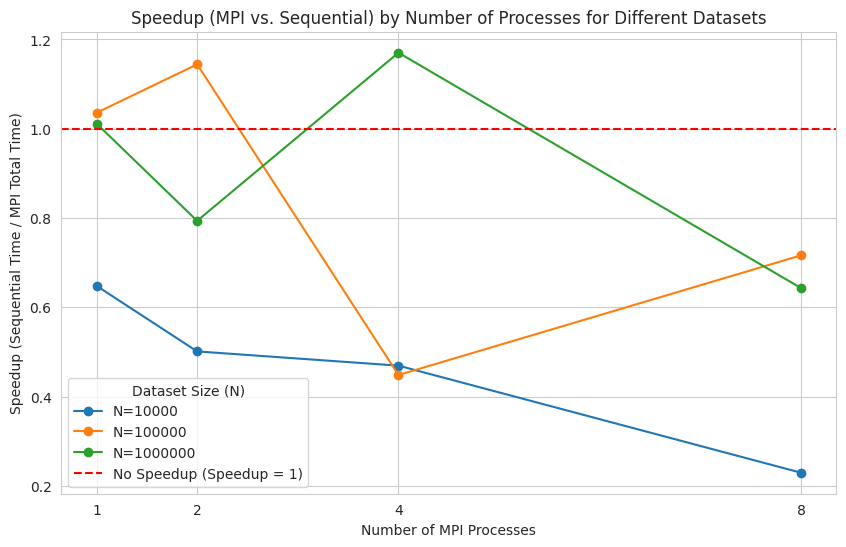

In [40]:
plot_speedup(performance_df)